<a href="https://colab.research.google.com/github/roughhawkbit/digi-inno-road-prod/blob/main/analysis/Analyse_BART_zero_shot_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
import matplotlib
import numpy
import os
import pandas
import sys

In [3]:
if IN_COLAB:
  dirpath = '/content/digi-inno-road-prod'
  if not os.path.isdir(dirpath):
    # TODO git pull
    !git clone https://github.com/roughhawkbit/digi-inno-road-prod.git
  sys.path.insert(0,dirpath)
else:
  module_path = os.path.abspath(os.path.join('..'))
  if not module_path in sys.path:
      sys.path.insert(0, module_path)

Cloning into 'digi-inno-road-prod'...
remote: Enumerating objects: 650, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 650 (delta 44), reused 2 (delta 2), pack-reused 584 (from 1)
Receiving objects: 100% (650/650), 1.64 MiB | 7.22 MiB/s, done.
Resolving deltas: 100% (409/409), done.


In [4]:
from innoprod.sheet_tools import get_sheet_dfs
from innoprod.plotting_tools import rand_jitter

# Read in data

In [5]:
all_results_df = get_sheet_dfs(
    sheet_id="1_ycDOfNq7khbzgdgF80qhHWmWpHC_9TGIwdDkkAvfvY",
    ranges={"Results": "Sheet1!A1:H3301"}
  )['Results']
# all_results_df

In [6]:
col_types = {
    'Client ID': 'str',
    'Current DRS': pandas.Int64Dtype(),
    'Core': 'str',
    'Category': 'str',
    'Question': 'str',
    'Prediction': 'int',
    'Probability': 'float',
    'Confidence': 'float'
}

all_results_df['Current DRS'] = all_results_df['Current DRS'].replace(to_replace='', value=numpy.nan)

for col, ty in col_types.items():
  all_results_df[col] = all_results_df[col].astype(ty)


# Filter results
Keep only the three questions within each W/C/C core that closely correlate with one another.

In [21]:
questions_to_keep = [
    # Willingness
    "Is the management team of the company open to working with academic or public organisations/networks to acquire new knowledge?",
    "Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?",
    "Is the company aware of the possibilities offered by emerging technologies and has it identified commercially-viable opportunities where they could add value to its current business?",

    # Capability
    "Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?",
    "Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",
    "Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?",

    # Capacity
    "Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?",
    "Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?",
    "Does the workforce of the company have the appropriate know-how to be able to facilitate the introduction of new technology or processes?",
]

kept_questions_mask = all_results_df['Question'].isin(questions_to_keep)

# Explore results

In [22]:
all_results_df[kept_questions_mask]['Prediction'].value_counts().sort_index()

,count
Prediction,
1,221
2,893
3,642
4,224


In [8]:
bart_output_cols = ['Prediction',	'Probability',	'Confidence']

In [23]:
all_results_df[kept_questions_mask][['Question']+bart_output_cols].groupby('Question').mean()

,Prediction,Probability,Confidence
Question,,,
Are continuous improvement methods embedded within the culture of the company's management and workforce in relation to technology and digital transformation?,2.545455,0.471695,0.590918
Does the company currently have the resources available to invest in new technologies and implement them in a cost-effective way?,2.109091,0.496618,0.677190
Does the company have a range of managerial skills and experience to translate its resources and capabilities into a competitive position within the market?,2.631818,0.439874,0.538312
Does the company have any highly-specialised skills and knowledge within the workforce that give it an advantage over competitors?,2.286364,0.501905,0.749744
"Does the company have efficient processes and related systems in appropriate areas (e.g. enterprise resource planning, quality-management, customer-relationship-management, etc.)?",2.295455,0.410332,0.413636
Does the company have the flexibility in its structures and processes to introduce new products or services in a way that minimises risk and potential disruption to BAU?,2.759091,0.512177,0.833896
Does the workforce of the company have the appropriate know-how to be able to facilitate the introduction of new technology or processes?,2.427273,0.475658,0.583040
Is the company aware of the possibilities offered by emerging technologies and has it identified commercially-viable opportunities where they could add value to its current business?,2.604545,0.488637,0.601446
Is the management team of the company open to working with academic or public organisations/networks to acquire new knowledge?,2.290909,0.544626,0.719421


In [24]:
client_average = all_results_df[kept_questions_mask].groupby('Client ID')[['Client ID', 'Prediction', 'Confidence']].apply(
    lambda x: numpy.average(x['Prediction']) #, weights=x['Confidence'])
  )

per_client_results = client_average.to_frame().reset_index()
per_client_results.columns = ['Client ID', 'Average']
per_client_results = pandas.merge(
    per_client_results,
    all_results_df[['Client ID', 'Current DRS']].drop_duplicates(),
    on="Client ID",
    how="left"
  )

per_client_results

,Client ID,Average,Current DRS
0,00CCFCC3-97CA-83F5-9E32-E34EBB545EE9,3.222222,6
1,01C7893A-F65C-A751-BF14-85C2422EEB21,3.000000,3
2,02ACA5CA-A427-85C2-83F1-641E6C24C3B7,1.555556,4
3,0369B4F9-9E83-E83D-9E6B-BF82E264A2BA,3.000000,4
4,03D6895D-CDC3-B045-0038-D67ED790CFEB,2.222222,4
...,...,...,...
215,eb08ecff-5bf9-e60a-9cbf-66e8050adf5a,1.888889,3
216,eedd9207-123a-0efe-b23c-666b0cc9fd64,2.000000,6
217,f02a9ef1-5fcd-5bf8-a059-673b3046b72a,2.666667,2
218,f0924673-4134-48c9-3570-66e93ff15a47,2.000000,4


In [25]:
per_client_results[['Average',	'Current DRS']].dropna().corr()

,Average,Current DRS
Average,1.000000,0.109062
Current DRS,0.109062,1.000000


Text(0, 0.5, 'Number of firms')

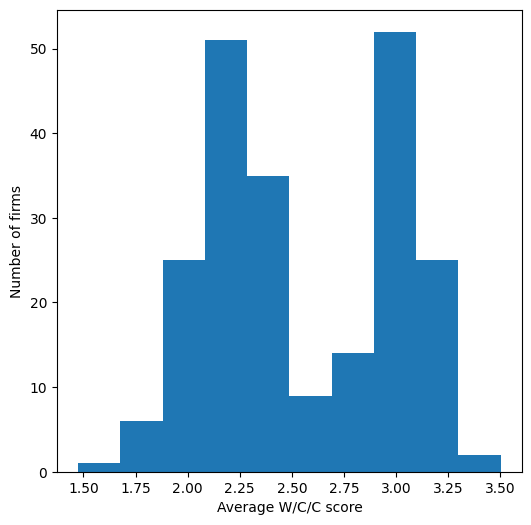

In [26]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
ax.hist(client_weighted_average.to_numpy())
ax.set_xlabel('Average W/C/C score') #, weighted by prediction confidence
ax.set_ylabel('Number of firms')

Text(0, 0.5, 'Average W/C/C score')

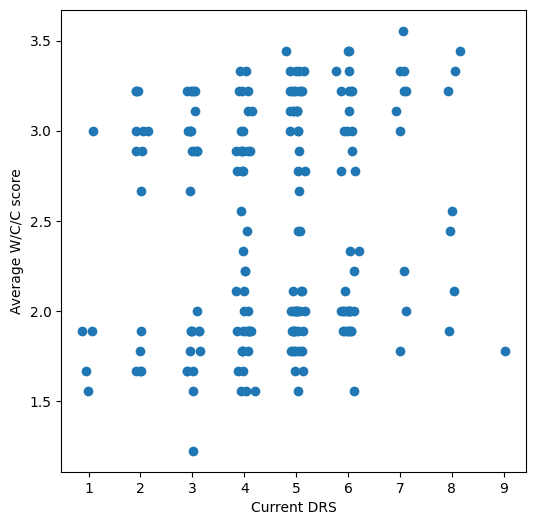

In [27]:
fig, ax = matplotlib.pyplot.subplots(figsize=(6,6))
X = per_client_results['Current DRS'].to_numpy().reshape(-1,1)
Y = per_client_results['Average'].to_numpy().reshape(-1,1)
ax.scatter(rand_jitter(X), Y)
ax.set_xlabel('Current DRS')
ax.set_ylabel('Average W/C/C score') #, weighted by prediction confidence